<a href="https://colab.research.google.com/github/charleneshen3/applied_datascience_project4/blob/main/summary_of_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading

In [ ]:
!pip install rdata -q

import rdata
import pandas as pd

def read_rds(path):
    parsed = rdata.parser.parse_file(path)
    return rdata.conversion.convert(parsed)

cm_obj = read_rds("all_cm_data.rds")
metrics_obj = read_rds("all_metrics.rds")

In [ ]:
rows = []

for ticker, models in cm_obj.items():
    for model_name, cm in models.items():
        df = pd.DataFrame(cm)
        df["ticker"] = str(ticker)
        df["model"] = str(model_name)
        rows.append(df)

cm_df = pd.concat(rows, ignore_index=True)
cm_df.head()

,Prediction,Reference,Freq,ticker,model
0,DOWN,DOWN,201,AAPL,lr
1,UP,DOWN,29,AAPL,lr
2,DOWN,UP,37,AAPL,lr
3,UP,UP,248,AAPL,lr
4,DOWN,DOWN,108,AAPL,rf


# Model Selection Table

In [ ]:
# =========================
# Load all_metrics.rds and compare average model performance
# =========================

!pip install rdata pandas numpy matplotlib -q

import os
import rdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Load RDS helper
# -------------------------
def read_rds(path):
    parsed = rdata.parser.parse_file(path)
    return rdata.conversion.convert(parsed)

# -------------------------
# Load all_metrics.rds
# -------------------------
if not os.path.exists("all_metrics.rds"):
    raise FileNotFoundError("all_metrics.rds is not in the current Colab Files directory.")

metrics_obj = read_rds("all_metrics.rds")

# Convert keys to normal Python strings
metrics_obj = {str(k): v for k, v in metrics_obj.items()}

# Flatten ticker-level into one pandas DataFrame
metric_rows = []

for ticker, df in metrics_obj.items():
    temp = pd.DataFrame(df).copy()
    temp["ticker"] = ticker
    metric_rows.append(temp)

metrics_df = pd.concat(metric_rows, ignore_index=True)

print("Loaded metrics_df:")
display(metrics_df)

# -------------------------
# Clean model names
# -------------------------
metrics_clean = metrics_df.copy()

model_name_map = {
    "lr": "Logistic Regression",
    "rf": "Random Forest",
    "xgb": "XGBoost",
    "Logistic Regression": "Logistic Regression",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost"
}

metrics_clean["model_clean"] = (
    metrics_clean["model"]
    .map(model_name_map)
    .fillna(metrics_clean["model"])
)

# -------------------------
# Make metric columns numeric
# -------------------------
metric_cols = ["accuracy", "sensitivity", "specificity", "precision", "recall", "f1", "auc"]

for col in metric_cols:
    metrics_clean[col] = pd.to_numeric(metrics_clean[col], errors="coerce")

# -------------------------
# Average performance across tickers
# -------------------------
avg_by_model = (
    metrics_clean
    .groupby("model_clean")[metric_cols]
    .mean()
    .sort_values("auc", ascending=False)
    .round(4)
    .reset_index()
)

print("Average performance by model across AAPL, NFLX, MSFT, and AMZN:")
display(avg_by_model)

# -------------------------
# Best model by ticker using AUC, then F1 as tie-breaker
# -------------------------
best_by_ticker = (
    metrics_clean
    .sort_values(["ticker", "auc", "f1"], ascending=[True, False, False])
    .groupby("ticker")
    .head(1)
    .reset_index(drop=True)
)

print("Best model by ticker:")
display(
    best_by_ticker[
        ["ticker", "model_clean", "accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]
    ].round(4)
)

Loaded metrics_df:


,model,accuracy,sensitivity,specificity,precision,recall,f1,auc,ticker
0,Logistic Regression,0.8718,0.8702,0.8739,0.8953,0.8702,0.8826,0.9409,AAPL
1,Random Forest,0.7456,0.9684,0.4696,0.6935,0.9684,0.8082,0.8518,AAPL
2,XGBoost,0.7806,0.9404,0.5826,0.7363,0.9404,0.8259,0.8684,AAPL
3,Logistic Regression,0.8971,0.9323,0.8594,0.8763,0.9323,0.9035,0.9666,NFLX
4,Random Forest,0.8602,0.9060,0.8112,0.8368,0.9060,0.8700,0.9508,NFLX
5,XGBoost,0.8718,0.9023,0.8394,0.8571,0.9023,0.8791,0.9515,NFLX
6,Logistic Regression,0.8311,0.8376,0.8238,0.8407,0.8376,0.8392,0.9228,MSFT
7,Random Forest,0.6641,0.9742,0.3197,0.6140,0.9742,0.7532,0.8525,MSFT
8,XGBoost,0.7592,0.9410,0.5574,0.7025,0.9410,0.8044,0.8818,MSFT
9,Logistic Regression,0.8602,0.8450,0.8770,0.8842,0.8450,0.8642,0.9453,AMZN


Average performance by model across AAPL, NFLX, MSFT, and AMZN:


,model_clean,accuracy,sensitivity,specificity,precision,recall,f1,auc
0,Logistic Regression,0.8650,0.8713,0.8585,0.8741,0.8713,0.8724,0.9439
1,XGBoost,0.8170,0.9072,0.7121,0.7933,0.9072,0.8426,0.9091
2,Random Forest,0.7782,0.9252,0.6081,0.7484,0.9252,0.8206,0.8941


Best model by ticker:


,ticker,model_clean,accuracy,sensitivity,specificity,precision,f1,auc
0,AAPL,Logistic Regression,0.8718,0.8702,0.8739,0.8953,0.8826,0.9409
1,AMZN,Logistic Regression,0.8602,0.8450,0.8770,0.8842,0.8642,0.9453
2,MSFT,Logistic Regression,0.8311,0.8376,0.8238,0.8407,0.8392,0.9228
3,NFLX,Logistic Regression,0.8971,0.9323,0.8594,0.8763,0.9035,0.9666


In [ ]:
# =========================
# Model stability across tickers
# Which model is most consistent?
# =========================

import pandas as pd
import numpy as np

# Use metrics_clean from Cell 1
# Columns should include: ticker, model_clean, accuracy, f1, auc, sensitivity, specificity

stability_summary = (
    metrics_clean
    .groupby("model_clean")[["accuracy", "f1", "auc", "sensitivity", "specificity"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print("Model stability across tickers:")
display(stability_summary)

# Flatten column names for easier use
stability_flat = stability_summary.copy()
stability_flat.columns = ["_".join(col).strip() for col in stability_flat.columns.values]
stability_flat = stability_flat.reset_index()

# Create a simple stability-adjusted score:
# High mean AUC is good; high AUC standard deviation is bad.
stability_flat["stability_adjusted_auc"] = (
    stability_flat["auc_mean"] - stability_flat["auc_std"]
).round(4)

# Also reward balanced sensitivity/specificity
stability_flat["balance_gap"] = (
    abs(stability_flat["sensitivity_mean"] - stability_flat["specificity_mean"])
).round(4)

stability_flat["overall_selection_score"] = (
    stability_flat["stability_adjusted_auc"] - 0.25 * stability_flat["balance_gap"]
).round(4)

model_selection_stability = (
    stability_flat[
        [
            "model_clean",
            "accuracy_mean",
            "f1_mean",
            "auc_mean",
            "auc_std",
            "stability_adjusted_auc",
            "sensitivity_mean",
            "specificity_mean",
            "balance_gap",
            "overall_selection_score"
        ]
    ]
    .sort_values("overall_selection_score", ascending=False)
)

print("Stability-adjusted model selection table:")
display(model_selection_stability)

Model stability across tickers:


accuracy                              f1                  \
                        mean     std     min     max    mean     std     min   
model_clean                                                                    
Logistic Regression   0.8650  0.0274  0.8311  0.8971  0.8724  0.0273  0.8392   
Random Forest         0.7782  0.0912  0.6641  0.8602  0.8206  0.0518  0.7532   
XGBoost               0.8170  0.0554  0.7592  0.8718  0.8426  0.0337  0.8044   

                                auc                         sensitivity  \
                        max    mean     std     min     max        mean   
model_clean                                                               
Logistic Regression  0.9035  0.9439  0.0180  0.9228  0.9666      0.8713   
Random Forest        0.8700  0.8941  0.0499  0.8518  0.9508      0.9252   
XGBoost              0.8791  0.9091  0.0402  0.8684  0.9515      0.9072   

                                            specificity                  \
                        std     min     max        mean     std     min   
model_clean                                                               
Logistic Regression  0.0430  0.8376  0.9323      0.8585  0.0244  0.8238   
Random Forest        0.0575  0.8524  0.9742      0.6081  0.2541  0.3197   
XGBoost              0.0452  0.8450  0.9410      0.7121  0.1648  0.5574   

                             
                        max  
model_clean                  
Logistic Regression  0.8770  
Random Forest        0.8320  
XGBoost              0.8689

Stability-adjusted model selection table:


,model_clean,accuracy_mean,f1_mean,auc_mean,auc_std,stability_adjusted_auc,sensitivity_mean,specificity_mean,balance_gap,overall_selection_score
0,Logistic Regression,0.8650,0.8724,0.9439,0.0180,0.9259,0.8713,0.8585,0.0128,0.9227
2,XGBoost,0.8170,0.8426,0.9091,0.0402,0.8689,0.9072,0.7121,0.1951,0.8201
1,Random Forest,0.7782,0.8206,0.8941,0.0499,0.8442,0.9252,0.6081,0.3171,0.7649


# Error-Analysis Table

In [ ]:
# =========================
# Load all_cm_data.rds and create error-analysis table
# =========================

import os
import rdata
import pandas as pd
import numpy as np

# -------------------------
# Load all_cm_data.rds
# -------------------------
if not os.path.exists("all_cm_data.rds"):
    raise FileNotFoundError("all_cm_data.rds is not in the current Colab Files directory.")

cm_obj = read_rds("all_cm_data.rds")
cm_obj = {str(k): v for k, v in cm_obj.items()}

# -------------------------
# Flatten confusion matrices
# -------------------------
rows = []

for ticker, models in cm_obj.items():
    for model_name, cm in models.items():
        temp = pd.DataFrame(cm).copy()
        temp["ticker"] = str(ticker)
        temp["model"] = str(model_name)
        rows.append(temp)

cm_df = pd.concat(rows, ignore_index=True)

# Clean model names
model_name_map = {
    "lr": "Logistic Regression",
    "rf": "Random Forest",
    "xgb": "XGBoost",
    "Logistic Regression": "Logistic Regression",
    "Random Forest": "Random Forest",
    "XGBoost": "XGBoost"
}

cm_df["model_clean"] = (
    cm_df["model"]
    .map(model_name_map)
    .fillna(cm_df["model"])
)

print("Flattened confusion matrix data:")
display(cm_df.head(12))

# -------------------------
# Convert confusion matrix to TN, FP, FN, TP
# -------------------------
def extract_confusion_counts(group):
    table = group.pivot_table(
        index="Prediction",
        columns="Reference",
        values="Freq",
        aggfunc="sum",
        fill_value=0
    )

    tn = table.loc["DOWN", "DOWN"] if "DOWN" in table.index and "DOWN" in table.columns else 0
    fp = table.loc["UP", "DOWN"] if "UP" in table.index and "DOWN" in table.columns else 0
    fn = table.loc["DOWN", "UP"] if "DOWN" in table.index and "UP" in table.columns else 0
    tp = table.loc["UP", "UP"] if "UP" in table.index and "UP" in table.columns else 0

    total = tn + fp + fn + tp

    return pd.Series({
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "total": total,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "predicted_up_rate": (fp + tp) / total if total > 0 else np.nan,
        "actual_up_rate": (fn + tp) / total if total > 0 else np.nan
    })

error_analysis = (
    cm_df
    .groupby(["ticker", "model_clean"])
    .apply(extract_confusion_counts)
    .reset_index()
)

round_cols = [
    "false_positive_rate",
    "false_negative_rate",
    "predicted_up_rate",
    "actual_up_rate"
]

error_analysis[round_cols] = error_analysis[round_cols].round(4)

print("Error-analysis table:")
display(error_analysis.sort_values(["ticker", "model_clean"]))

# -------------------------
# Average error behavior by model
# -------------------------
avg_error_by_model = (
    error_analysis
    .groupby("model_clean")[["FP", "FN", "false_positive_rate", "false_negative_rate", "predicted_up_rate"]]
    .mean()
    .round(4)
    .reset_index()
)

print("Average error behavior by model:")
display(avg_error_by_model)

Flattened confusion matrix data:


,Prediction,Reference,Freq,ticker,model,model_clean
0,DOWN,DOWN,201,AAPL,lr,Logistic Regression
1,UP,DOWN,29,AAPL,lr,Logistic Regression
2,DOWN,UP,37,AAPL,lr,Logistic Regression
3,UP,UP,248,AAPL,lr,Logistic Regression
4,DOWN,DOWN,108,AAPL,rf,Random Forest
5,UP,DOWN,122,AAPL,rf,Random Forest
6,DOWN,UP,9,AAPL,rf,Random Forest
7,UP,UP,276,AAPL,rf,Random Forest
8,DOWN,DOWN,134,AAPL,xgb,XGBoost
9,UP,DOWN,96,AAPL,xgb,XGBoost


Error-analysis table:


,ticker,model_clean,TN,FP,FN,TP,total,false_positive_rate,false_negative_rate,predicted_up_rate,actual_up_rate
0,AAPL,Logistic Regression,201.0,29.0,37.0,248.0,515.0,0.1261,0.1298,0.5379,0.5534
1,AAPL,Random Forest,108.0,122.0,9.0,276.0,515.0,0.5304,0.0316,0.7728,0.5534
2,AAPL,XGBoost,134.0,96.0,17.0,268.0,515.0,0.4174,0.0596,0.7068,0.5534
3,AMZN,Logistic Regression,214.0,30.0,42.0,229.0,515.0,0.1230,0.1550,0.5029,0.5262
4,AMZN,Random Forest,203.0,41.0,40.0,231.0,515.0,0.1680,0.1476,0.5282,0.5262
5,AMZN,XGBoost,212.0,32.0,42.0,229.0,515.0,0.1311,0.1550,0.5068,0.5262
6,MSFT,Logistic Regression,201.0,43.0,44.0,227.0,515.0,0.1762,0.1624,0.5243,0.5262
7,MSFT,Random Forest,78.0,166.0,7.0,264.0,515.0,0.6803,0.0258,0.8350,0.5262
8,MSFT,XGBoost,136.0,108.0,16.0,255.0,515.0,0.4426,0.0590,0.7049,0.5262
9,NFLX,Logistic Regression,214.0,35.0,18.0,248.0,515.0,0.1406,0.0677,0.5495,0.5165


Average error behavior by model:


,model_clean,FP,FN,false_positive_rate,false_negative_rate,predicted_up_rate
0,Logistic Regression,34.25,35.25,0.1415,0.1287,0.5287
1,Random Forest,94.00,20.25,0.3919,0.0748,0.6738
2,XGBoost,69.00,25.25,0.2879,0.0928,0.6156


# Baseline Comparison

In [ ]:
# =========================
# Majority-class baseline comparison
# Uses test-set class balance from the confusion matrices
# =========================

import pandas as pd
import numpy as np

# -------------------------
# Get actual class balance from one model's confusion matrix per ticker
# Since all models use the same test set, use Logistic Regression rows
# -------------------------
one_model_cm = cm_df[cm_df["model_clean"] == "Logistic Regression"].copy()

class_balance = (
    one_model_cm
    .groupby(["ticker", "Reference"])["Freq"]
    .sum()
    .reset_index()
    .pivot(index="ticker", columns="Reference", values="Freq")
    .fillna(0)
)

class_balance["total"] = class_balance.sum(axis=1)
class_balance["UP_rate"] = class_balance.get("UP", 0) / class_balance["total"]
class_balance["DOWN_rate"] = class_balance.get("DOWN", 0) / class_balance["total"]
class_balance["majority_class"] = np.where(
    class_balance["UP_rate"] >= class_balance["DOWN_rate"],
    "UP",
    "DOWN"
)
class_balance["majority_baseline_accuracy"] = class_balance[["UP_rate", "DOWN_rate"]].max(axis=1)

print("Test-set class balance and majority-class baseline:")
display(class_balance.round(4))

# -------------------------
# Compare each model's accuracy to the majority baseline
# -------------------------
baseline_lookup = class_balance["majority_baseline_accuracy"].to_dict()

baseline_comparison = metrics_clean.copy()
baseline_comparison["majority_baseline_accuracy"] = baseline_comparison["ticker"].map(baseline_lookup)
baseline_comparison["accuracy_gain_vs_baseline"] = (
    baseline_comparison["accuracy"] - baseline_comparison["majority_baseline_accuracy"]
)

baseline_comparison_display = baseline_comparison[
    [
        "ticker",
        "model_clean",
        "accuracy",
        "majority_baseline_accuracy",
        "accuracy_gain_vs_baseline",
        "f1",
        "auc"
    ]
].sort_values(["ticker", "accuracy_gain_vs_baseline"], ascending=[True, False])

print("Model accuracy gain over majority-class baseline:")
display(baseline_comparison_display.round(4))

# -------------------------
# Average gain by model
# -------------------------
avg_gain_by_model = (
    baseline_comparison
    .groupby("model_clean")[["accuracy_gain_vs_baseline", "accuracy", "f1", "auc"]]
    .mean()
    .sort_values("accuracy_gain_vs_baseline", ascending=False)
    .round(4)
    .reset_index()
)

print("Average gain over majority-class baseline by model:")
display(avg_gain_by_model)

Test-set class balance and majority-class baseline:


Reference,DOWN,UP,total,UP_rate,DOWN_rate,majority_class,majority_baseline_accuracy
ticker,,,,,,,
AAPL,230,285,515,0.5534,0.4466,UP,0.5534
AMZN,244,271,515,0.5262,0.4738,UP,0.5262
MSFT,244,271,515,0.5262,0.4738,UP,0.5262
NFLX,249,266,515,0.5165,0.4835,UP,0.5165


Model accuracy gain over majority-class baseline:


,ticker,model_clean,accuracy,majority_baseline_accuracy,accuracy_gain_vs_baseline,f1,auc
0,AAPL,Logistic Regression,0.8718,0.5534,0.3184,0.8826,0.9409
2,AAPL,XGBoost,0.7806,0.5534,0.2272,0.8259,0.8684
1,AAPL,Random Forest,0.7456,0.5534,0.1922,0.8082,0.8518
9,AMZN,Logistic Regression,0.8602,0.5262,0.3340,0.8642,0.9453
11,AMZN,XGBoost,0.8563,0.5262,0.3301,0.8609,0.9348
10,AMZN,Random Forest,0.8427,0.5262,0.3165,0.8508,0.9214
6,MSFT,Logistic Regression,0.8311,0.5262,0.3049,0.8392,0.9228
8,MSFT,XGBoost,0.7592,0.5262,0.2330,0.8044,0.8818
7,MSFT,Random Forest,0.6641,0.5262,0.1379,0.7532,0.8525
3,NFLX,Logistic Regression,0.8971,0.5165,0.3806,0.9035,0.9666


Average gain over majority-class baseline by model:


,model_clean,accuracy_gain_vs_baseline,accuracy,f1,auc
0,Logistic Regression,0.3345,0.8650,0.8724,0.9439
1,XGBoost,0.2864,0.8170,0.8426,0.9091
2,Random Forest,0.2476,0.7782,0.8206,0.8941


# Ticker Difficulty Analysis

In [ ]:
# =========================
# Ticker difficulty analysis
# Which stocks are easiest/hardest to classify?
# =========================

import pandas as pd
import numpy as np

ticker_difficulty = (
    metrics_clean
    .groupby("ticker")[["accuracy", "f1", "auc", "sensitivity", "specificity"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print("Ticker-level performance summary:")
display(ticker_difficulty)

# Flatten columns for easier ranking
ticker_difficulty_flat = ticker_difficulty.copy()
ticker_difficulty_flat.columns = ["_".join(col).strip() for col in ticker_difficulty_flat.columns.values]
ticker_difficulty_flat = ticker_difficulty_flat.reset_index()

# Higher average AUC/F1 means easier to classify
ticker_difficulty_flat["classification_ease_score"] = (
    0.6 * ticker_difficulty_flat["auc_mean"] +
    0.4 * ticker_difficulty_flat["f1_mean"]
).round(4)

ticker_difficulty_ranked = (
    ticker_difficulty_flat[
        [
            "ticker",
            "accuracy_mean",
            "f1_mean",
            "auc_mean",
            "sensitivity_mean",
            "specificity_mean",
            "classification_ease_score"
        ]
    ]
    .sort_values("classification_ease_score", ascending=False)
)

print("Ticker difficulty ranking:")
display(ticker_difficulty_ranked)

Ticker-level performance summary:


accuracy                              f1                          \
           mean     std     min     max    mean     std     min     max   
ticker                                                                    
AAPL     0.7993  0.0652  0.7456  0.8718  0.8389  0.0389  0.8082  0.8826   
AMZN     0.8531  0.0092  0.8427  0.8602  0.8586  0.0070  0.8508  0.8642   
MSFT     0.7515  0.0838  0.6641  0.8311  0.7989  0.0433  0.7532  0.8392   
NFLX     0.8764  0.0189  0.8602  0.8971  0.8842  0.0173  0.8700  0.9035   

           auc                         sensitivity                          \
          mean     std     min     max        mean     std     min     max   
ticker                                                                       
AAPL    0.8870  0.0474  0.8518  0.9409      0.9263  0.0506  0.8702  0.9684   
AMZN    0.9338  0.0120  0.9214  0.9453      0.8475  0.0043  0.8450  0.8524   
MSFT    0.8857  0.0353  0.8525  0.9228      0.9176  0.0712  0.8376  0.9742   
NFLX    0.9563  0.0089  0.9508  0.9666      0.9135  0.0164  0.9023  0.9323   

       specificity                          
              mean     std     min     max  
ticker                                      
AAPL        0.6420  0.2086  0.4696  0.8739  
AMZN        0.8593  0.0240  0.8320  0.8770  
MSFT        0.5670  0.2522  0.3197  0.8238  
NFLX        0.8367  0.0242  0.8112  0.8594

Ticker difficulty ranking:


,ticker,accuracy_mean,f1_mean,auc_mean,sensitivity_mean,specificity_mean,classification_ease_score
3,NFLX,0.8764,0.8842,0.9563,0.9135,0.8367,0.9275
1,AMZN,0.8531,0.8586,0.9338,0.8475,0.8593,0.9037
0,AAPL,0.7993,0.8389,0.8870,0.9263,0.6420,0.8678
2,MSFT,0.7515,0.7989,0.8857,0.9176,0.5670,0.8510


# Metric Correlation Analysis

Correlation among evaluation metrics:


,accuracy,sensitivity,specificity,precision,recall,f1,auc
accuracy,1.000,-0.673,0.972,0.972,-0.673,0.985,0.942
sensitivity,-0.673,1.000,-0.824,-0.807,1.000,-0.549,-0.644
specificity,0.972,-0.824,1.000,0.993,-0.824,0.921,0.932
precision,0.972,-0.807,0.993,1.000,-0.807,0.934,0.926
recall,-0.673,1.000,-0.824,-0.807,1.000,-0.549,-0.644
f1,0.985,-0.549,0.921,0.934,-0.549,1.000,0.921
auc,0.942,-0.644,0.932,0.926,-0.644,0.921,1.000


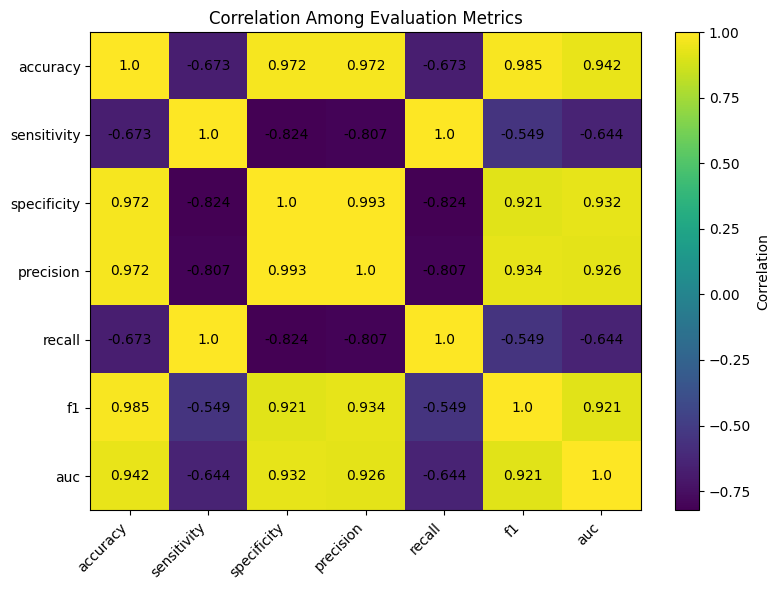

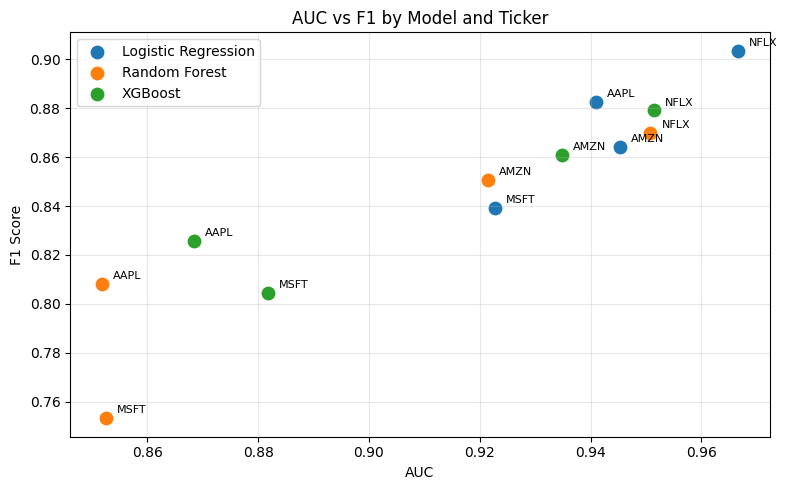

In [ ]:
# =========================
# Metric correlation analysis
# Do the evaluation metrics agree with each other?
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

metric_cols = ["accuracy", "sensitivity", "specificity", "precision", "recall", "f1", "auc"]

# Correlation matrix across all ticker-model combinations
metric_corr = metrics_clean[metric_cols].corr().round(3)

print("Correlation among evaluation metrics:")
display(metric_corr)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
plt.imshow(metric_corr, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(metric_cols)), metric_cols, rotation=45, ha="right")
plt.yticks(range(len(metric_cols)), metric_cols)

for i in range(len(metric_cols)):
    for j in range(len(metric_cols)):
        plt.text(j, i, metric_corr.iloc[i, j], ha="center", va="center")

plt.title("Correlation Among Evaluation Metrics")
plt.tight_layout()
plt.show()

# AUC vs F1 scatter
plt.figure(figsize=(8, 5))

for model in metrics_clean["model_clean"].unique():
    subset = metrics_clean[metrics_clean["model_clean"] == model]
    plt.scatter(subset["auc"], subset["f1"], s=80, label=model)

for _, row in metrics_clean.iterrows():
    plt.text(row["auc"] + 0.002, row["f1"] + 0.002, row["ticker"], fontsize=8)

plt.xlabel("AUC")
plt.ylabel("F1 Score")
plt.title("AUC vs F1 by Model and Ticker")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()